In [1]:
import os
import pickle
import pandas as pd
import math
import random
import numpy as np
import os

import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from SetTransformer import *
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support


In [2]:
listModels = ["settransformer", "settransformer_w_pma", "settransformer_ch1", "settransformer_w_pma_ch1", "conv_topk", "conv_lse", "abmil", "dsmil", "deepsets", "mil", "picaso", "pointnetpp", "deepsvdd"]
listDfs = []
for num in range(1, 11):
    for modelName in listModels:
        try:
            with open(f'data/260322_ST_Comparison/score/dictLoss_{modelName}_{num}.pkl', 'rb') as f:
                dictLoss = pickle.load(f)
            dfModel = pd.DataFrame.from_dict(dictLoss, orient='columns')
            dfModel['depart'] = modelName
            dfModel['num'] = num
            listDfs.append(dfModel)
        except:
            pass
        
dfScores = pd.concat(listDfs, axis=0)
dfScores

,epoch,train,thr,prec,rec,f1,auroc,auprc,depart,num
0,000,0.7430,0.05,0.3718,1.0000,0.5421,0.3854,0.3151,settransformer,1
1,001,0.4553,0.05,0.3718,1.0000,0.5421,0.4181,0.3200,settransformer,1
2,002,0.2388,0.05,0.3718,1.0000,0.5421,0.4141,0.3181,settransformer,1
3,003,0.1134,0.05,0.3718,1.0000,0.5421,0.4148,0.3214,settransformer,1
4,004,0.0544,0.05,0.3718,1.0000,0.5421,0.4109,0.3151,settransformer,1
...,...,...,...,...,...,...,...,...,...,...
95,095,0.3050,0.90,0.8742,0.9314,0.9019,0.9718,0.9450,settransformer_w_pma,3
96,096,0.2845,0.70,0.8563,0.9346,0.8938,0.9665,0.9396,settransformer_w_pma,3
97,097,0.2805,0.35,0.8550,0.9444,0.8975,0.9682,0.9403,settransformer_w_pma,3
98,098,0.3265,0.70,0.8563,0.9542,0.9026,0.9710,0.9443,settransformer_w_pma,3


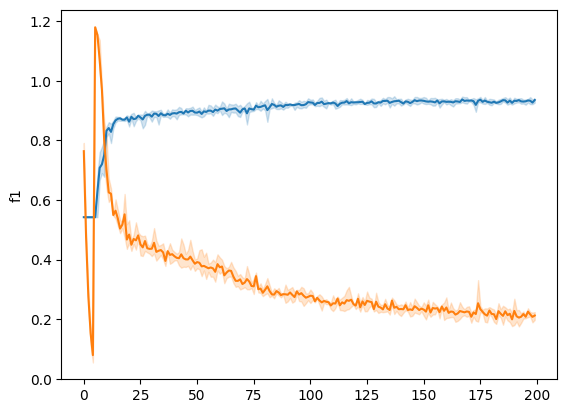

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
dfTemp = dfScores.loc[dfScores.depart == 'settransformer', :]
sns.lineplot(dfTemp['f1'].astype(float))
sns.lineplot(dfTemp['train'].astype(float))
plt.show()

In [5]:
dfMax.loc[dfMax.depart == 'settransformer', :]

,depart,num,f1
60,settransformer,1,0.9482
61,settransformer,2,0.9408
62,settransformer,3,0.9335
63,settransformer,4,0.9248
64,settransformer,5,0.5421
65,settransformer,6,0.5421
66,settransformer,7,0.5421
67,settransformer,8,0.9450


In [3]:
dfScores[['train', 'thr', 'prec', 'rec', 'f1']] = dfScores[['train', 'thr', 'prec', 'rec', 'f1']].astype(float)
dfMax = dfScores.groupby(['depart', 'num'])['f1'].max().reset_index()#.groupby('depart')['f1'].apply(np.mean).reset_index()
dfMax

,depart,num,f1
0,abmil,1,0.8994
1,abmil,2,0.8911
2,conv_lse,1,0.9410
3,conv_lse,2,0.9306
4,conv_topk,1,0.9412
5,conv_topk,2,0.9361
6,deepsets,1,0.8794
7,deepsets,2,0.9083
8,deepsvdd,1,0.8816
9,deepsvdd,2,0.9035


In [4]:
dictThr = {}
for idx, row in dfMax.iterrows():
    # dictThr[f'{row.depart}_{row.num}'] = float(dfScores.loc[(dfScores.depart == row.depart) & (dfScores.num == row.num) & (dfScores.f1 == row.f1), 'thr'].iloc[0].item())
    dictThr[f'{row.depart}_{row.num}'] = (dfScores.loc[(dfScores.depart == row.depart) & (dfScores.num == row.num) & (dfScores.f1 == row.f1), ['depart', 'thr', 'epoch']].iloc[0])
dictThr

    

{'abmil_1': depart    abmil
 thr         0.8
 epoch       199
 Name: 199, dtype: object,
 'abmil_2': depart    abmil
 thr        0.85
 epoch       192
 Name: 192, dtype: object,
 'conv_lse_1': depart    conv_lse
 thr            0.1
 epoch          190
 Name: 190, dtype: object,
 'conv_lse_2': depart    conv_lse
 thr           0.55
 epoch          168
 Name: 168, dtype: object,
 'conv_topk_1': depart    conv_topk
 thr            0.15
 epoch           104
 Name: 104, dtype: object,
 'conv_topk_2': depart    conv_topk
 thr             0.6
 epoch           191
 Name: 191, dtype: object,
 'deepsets_1': depart    deepsets
 thr           0.65
 epoch          147
 Name: 147, dtype: object,
 'deepsets_2': depart    deepsets
 thr           0.55
 epoch          185
 Name: 185, dtype: object,
 'deepsvdd_1': depart    deepsvdd
 thr           0.75
 epoch          189
 Name: 189, dtype: object,
 'deepsvdd_2': depart    deepsvdd
 thr            0.6
 epoch          176
 Name: 176, dtype: object,
 'dsmi

In [5]:
# ============================================================
# 1) Dataset / DataLoader (list of (H,W,3 tensor, scalar label tensor))
# ============================================================
class TensorLabelListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        if not torch.is_tensor(x):
            x = torch.tensor(x)
        if not torch.is_tensor(y):
            y = torch.tensor(y)
        assert x.dim() == 3 and x.size(-1) == 3, f"x must be (H,W,3), got {tuple(x.shape)}"
        y = y.squeeze()
        assert y.dim() == 0, f"y must be scalar, got {tuple(y.shape)}"
        return x, y

def collate_bhw3_with_mask(batch):
    xs, ys = zip(*batch)
    B = len(xs)
    dtype = xs[0].dtype
    Hmax = max(x.shape[0] for x in xs)
    Wmax = max(x.shape[1] for x in xs)

    X = torch.zeros((B, Hmax, Wmax, 3), dtype=dtype)
    mask = torch.zeros((B, Hmax, Wmax), dtype=torch.bool)

    for i, x in enumerate(xs):
        H, W, C = x.shape
        assert C == 3
        X[i, :H, :W] = x
        mask[i, :H, :W] = True

    y = torch.stack([yy.float() for yy in ys], dim=0)  # (B,)
    return X, mask, y

def collate_bhw3_with_mask_batch1(batch):
    xs, ys = zip(*batch)
    B = len(xs)
    dtype = xs[0].dtype
    Hmax = max(x.shape[0] for x in xs)
    Wmax = max(x.shape[1] for x in xs)

    # X = torch.zeros((B, Hmax, Wmax, 3), dtype=dtype)
    mask = torch.full((Hmax, Wmax), True, dtype=torch.bool)
    X = xs[0]
    yy = ys[0]
    # for i, x in enumerate(xs):
    #     H, W, C = x.shape
    #     assert C == 3
    #     X[i, :H, :W] = x
    #     mask[i, :H, :W] = True

    y = torch.stack([yy.float() for _ in range(Hmax)], dim=0)  # (B,)
    return X, mask, y

def make_loaders(train_list, val_list, batch_size=16, num_workers=0, pin_memory=False):
    train_ds = TensorLabelListDataset(train_list)
    val_ds = TensorLabelListDataset(val_list)
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, #persistent_workers=True, 
        pin_memory=pin_memory, collate_fn=collate_bhw3_with_mask if batch_size>1 else collate_bhw3_with_mask_batch1, drop_last=False
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, #persistent_workers=True, 
        pin_memory=pin_memory, collate_fn=collate_bhw3_with_mask if batch_size>1 else collate_bhw3_with_mask_batch1, drop_last=False
    )
    return train_loader, val_loader

# ============================================================
# 2) Common utils
# ============================================================
def grid_to_points(x_bhw3: torch.Tensor, mask_bhw: torch.Tensor | None = None):
    B, H, W, C = x_bhw3.shape
    assert C == 3
    X = x_bhw3.view(B, H * W, 3)
    mask = None
    if mask_bhw is not None:
        mask = mask_bhw.view(B, H * W).bool()
    return X, mask

def masked_sum(x: torch.Tensor, mask: torch.Tensor | None, dim: int):
    if mask is None:
        return x.sum(dim=dim)
    m = mask.float()
    while m.dim() < x.dim():
        m = m.unsqueeze(-1)
    return (x * m).sum(dim=dim)

def masked_mean(x: torch.Tensor, mask: torch.Tensor | None, dim: int):
    if mask is None:
        return x.mean(dim=dim)
    m = mask.float()
    while m.dim() < x.dim():
        m = m.unsqueeze(-1)
    denom = m.sum(dim=dim).clamp_min(1.0)
    return (x * m).sum(dim=dim) / denom

def masked_softmax(logits: torch.Tensor, mask: torch.Tensor | None, dim: int):
    if mask is None:
        return torch.softmax(logits, dim=dim)
    while mask.dim() < logits.dim():
        mask = mask.unsqueeze(-1)
    logits = logits.masked_fill(~mask, float("-inf"))
    return torch.softmax(logits, dim=dim)

def masked_mse(a: torch.Tensor, b: torch.Tensor, mask: torch.Tensor | None):
    diff2 = (a - b) ** 2
    if mask is None:
        return diff2.mean()
    m = mask.float().unsqueeze(-1)
    num = (diff2 * m).sum()
    den = m.sum().clamp_min(1.0)
    return num / den

def set_stats(x: torch.Tensor, mask: torch.Tensor | None = None):
    if mask is None:
        m = x.mean(dim=1)
        v = x.var(dim=1, unbiased=False).clamp_min(1e-12)
        return m, v.sqrt()
    m_f = mask.float().unsqueeze(-1)
    count = m_f.sum(dim=1).clamp_min(1.0)
    m = (x * m_f).sum(dim=1) / count
    v = (((x - m.unsqueeze(1)) ** 2) * m_f).sum(dim=1) / count
    return m, v.clamp_min(1e-12).sqrt()

def weak_augment_score(score: torch.Tensor, mask: torch.Tensor | None = None,
                       jitter_std=0.02, drop_rate=0.10, scale_std=0.02, shift_std=0.02):
    B, N, _ = score.shape
    out = score.clone()
    out = out + torch.randn_like(out) * jitter_std
    scale = (1.0 + torch.randn(B, 1, 1, device=score.device) * scale_std).clamp(0.9, 1.1)
    shift = torch.randn(B, 1, 1, device=score.device) * shift_std
    out = out * scale + shift
    if mask is None:
        m = torch.ones(B, N, device=score.device, dtype=torch.bool)
    else:
        m = mask.clone()
    if drop_rate > 0:
        keep = (torch.rand(B, N, device=score.device) > drop_rate)
        m = m & keep
    return out, m

def info_nce(z1: torch.Tensor, z2: torch.Tensor, temperature=0.2):
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    B = z1.size(0)
    logits = (z1 @ z2.t()) / temperature
    labels = torch.arange(B, device=z1.device)
    return F.cross_entropy(logits, labels)

# ============================================================
# 3) Focal loss + metrics
# ============================================================
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.9, gamma=2.0, reduction="mean"):
        super().__init__()
        assert reduction in ("none", "mean", "sum")
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        mod = (1 - p_t).clamp_min(1e-8) ** self.gamma
        loss = alpha_t * mod * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

@torch.no_grad()
def eval_f1_from_logits(logits: torch.Tensor, y: torch.Tensor, thr=0.5):
    prob = torch.sigmoid(logits)
    pred = (prob >= thr).float()
    y = y.float()
    tp = ((pred == 1) & (y == 1)).sum().item()
    tn = ((pred == 0) & (y == 0)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()
    if (tp + fp) == 0: precision = 0
    else: precision = tp / (tp + fp)
    if (tp + fn) == 0: recall = 0
    else: recall = tp / (tp + fn)
    if (precision + recall) == 0: f1 = 0
    else: f1 = 2 * precision * recall / (precision + recall)
    return {"f1": f1, "precision": precision, "recall": recall, "tp": tp, "tn": tn, "fp": fp, "fn": fn}

@torch.no_grad()
def eval_binary_metrics_from_logits(logits: torch.Tensor, y: torch.Tensor, thr=0.5):
    prob = torch.sigmoid(logits).detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().astype(int)
    pred = (prob >= thr).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_np, pred, average="binary", zero_division=0
    )

    tp = int(((pred == 1) & (y_np == 1)).sum())
    tn = int(((pred == 0) & (y_np == 0)).sum())
    fp = int(((pred == 1) & (y_np == 0)).sum())
    fn = int(((pred == 0) & (y_np == 1)).sum())

    return {
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

@torch.no_grad()
def find_best_threshold(model, loader, device, thresholds=None):
    model.eval()
    all_logits, all_y = [], []

    for X, mask, y in loader:
        X = X.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits = model(X, mask)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    y = torch.cat(all_y, dim=0)

    prob = torch.sigmoid(logits).numpy()
    y_np = y.numpy().astype(int)

    try:
        auroc = roc_auc_score(y_np, prob)
    except ValueError:
        auroc = float("nan")

    try:
        auprc = average_precision_score(y_np, prob)
    except ValueError:
        auprc = float("nan")

    if thresholds is None:
        thresholds = torch.linspace(0.05, 0.95, 19)

    best = {
        "thr": 0.5,
        "f1": -1.0,
        "precision": 0.0,
        "recall": 0.0,
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        "tp": 0, "tn": 0, "fp": 0, "fn": 0,
    }

    for thr in thresholds:
        m = eval_binary_metrics_from_logits(logits, y, thr=float(thr))
        if m["f1"] > best["f1"]:
            best = {
                "thr": float(thr),
                "f1": m["f1"],
                "precision": m["precision"],
                "recall": m["recall"],
                "tp": m["tp"],
                "tn": m["tn"],
                "fp": m["fp"],
                "fn": m["fn"],
                "AUROC": float(auroc),
                "AUPRC": float(auprc),
            }
    return best

# ============================================================
# 4) Supervised-only baselines
#    (DeepSets, Gated Attn MIL, PICASO, PointNet++, "Supervised DeepSVDD")
# ============================================================

@torch.no_grad()
def masked_fps(points, mask, M):
    """
    points: [B,N,3]
    mask:   [B,N] (True valid)
    returns idx: [B,M]
    """
    B, N, _ = points.shape
    device = points.device
    idx = torch.zeros((B, M), dtype=torch.long, device=device)

    for b in range(B):
        valid = torch.where(mask[b])[0]
        if valid.numel() == 0:
            continue

        sel = torch.empty((M,), dtype=torch.long, device=device)
        sel[0] = valid[0]

        dist = torch.full((N,), float("inf"), device=device)
        dist[~mask[b]] = -1.0

        last = sel[0].item()
        for m in range(1, M):
            d = ((points[b] - points[b, last:last+1]) ** 2).sum(-1)
            dist = torch.minimum(dist, d)
            dist[~mask[b]] = -1.0
            last = int(dist.argmax().item())
            if dist[last] < 0:
                last = int(sel[m-1].item())
            sel[m] = last

        idx[b] = sel
    return idx

def knn_group(points, centers, mask, k):
    """
    points:  [B,N,3]
    centers: [B,M,3]
    mask:    [B,N]
    returns nbr_pts: [B,M,k,3]
    """
    dist = torch.cdist(centers, points)                  # [B,M,N]
    dist = dist.masked_fill(~mask[:, None, :], 1e9)      # invalid => far
    nbr_idx = dist.topk(k=min(k, points.size(1)), dim=-1, largest=False).indices  # [B,M,k]

    B, M, kk = nbr_idx.shape
    idx_exp = nbr_idx[..., None].expand(B, M, kk, 3)
    nbr_pts = torch.gather(points[:, None, :, :].expand(B, M, -1, 3), 2, idx_exp)
    return nbr_pts

class NeighborhoodEncoder(nn.Module):
    """
    center + neighbors -> token
    """
    def __init__(self, token_dim=128, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(6, token_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(token_dim, token_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, centers, nbr_pts):
        # centers: [B,M,3], nbr_pts: [B,M,k,3]
        rel = nbr_pts - centers[:, :, None, :]            # [B,M,k,3]
        feat = torch.cat([nbr_pts, rel], dim=-1)          # [B,M,k,6]
        h = self.mlp(feat)                                # [B,M,k,D]
        tok = h.max(dim=2).values                         # [B,M,D]
        return tok

class FPSTokenizer(nn.Module):
    def __init__(self, M=256, k=16, token_dim=128, dropout=0.1):
        super().__init__()
        self.M = M
        self.k = k
        self.enc = NeighborhoodEncoder(token_dim=token_dim, dropout=dropout)

    def forward(self, points, mask):
        # points [B,N,3], mask [B,N]
        idx = masked_fps(points, mask, self.M)  # [B,M]
        centers = torch.gather(points, 1, idx[..., None].expand(-1, -1, 3))  # [B,M,3]
        nbr_pts = knn_group(points, centers, mask, self.k)                   # [B,M,k,3]
        tokens = self.enc(centers, nbr_pts)                                  # [B,M,D]
        return tokens
    
# ---- DeepSets ----
class DeepSetsBinary(nn.Module):
    def __init__(self, hidden=128, pooling="mean", dropout=0.1):
        super().__init__()
        assert pooling in ("mean", "sum")
        self.pooling = pooling
        self.phi = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True)
        )
        self.rho = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        h = self.phi(X)
        g = masked_mean(h, mask, 1) if self.pooling == "mean" else masked_sum(h, mask, 1)
        return self.rho(g).squeeze(-1)

# ---- Gated Attention MIL (Ilse et al.) ----
class GatedAttnMILBinary(nn.Module):
    def __init__(self, hidden=128, attn=64, dropout=0.1):
        super().__init__()
        self.inst = nn.Sequential(nn.Linear(3, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.V = nn.Linear(hidden, attn)
        self.U = nn.Linear(hidden, attn)
        self.w = nn.Linear(attn, 1, bias=False)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        H = self.inst(X)                                   # (B,N,H)
        A = torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))
        a_logits = self.w(A).squeeze(-1)                   # (B,N)
        alpha = masked_softmax(a_logits, mask, dim=1)      # (B,N)
        z = torch.sum(H * alpha.unsqueeze(-1), dim=1)
        return self.head(z).squeeze(-1)

# ---- PICASO-style (dynamic templates + cross-attn) ----
class FF(nn.Module):
    def __init__(self, d, dff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, dff), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(dff, d), nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)

class PICASOBlock(nn.Module):
    def __init__(self, d, heads, dff, dropout=0.1):
        super().__init__()
        self.attn_T = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.attn_X = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.lnT1 = nn.LayerNorm(d); self.lnT2 = nn.LayerNorm(d)
        self.lnX1 = nn.LayerNorm(d); self.lnX2 = nn.LayerNorm(d)
        self.ffT = FF(d, dff, dropout); self.ffX = FF(d, dff, dropout)

    def forward(self, X, T, mask_X=None):
        kpm = None
        if mask_X is not None: kpm = ~mask_X  # True padding
        T2, _ = self.attn_T(T, X, X, key_padding_mask=kpm, need_weights=False)
        T = self.lnT1(T + T2)
        T = self.lnT2(T + self.ffT(T))

        X2, _ = self.attn_X(X, T, T, need_weights=False)
        X = self.lnX1(X + X2)
        X = self.lnX2(X + self.ffX(X))
        return X, T

class PICASOBinary(nn.Module):
    def __init__(self, d=128, heads=4, dff=256, layers=2, templates=16, pooling="mean", dropout=0.1):
        super().__init__()
        assert pooling in ("mean", "sum")
        self.pooling = pooling
        self.in_proj = nn.Linear(3, d)
        self.T0 = nn.Parameter(torch.randn(templates, d) / math.sqrt(d))
        self.blocks = nn.ModuleList([PICASOBlock(d, heads, dff, dropout) for _ in range(layers)])
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, 1))

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        X = self.in_proj(X)
        B = X.size(0)
        T = self.T0.unsqueeze(0).expand(B, -1, -1).contiguous()
        for blk in self.blocks:
            X, T = blk(X, T, mask_X=mask)
        g = masked_mean(X, mask, 1) if self.pooling == "mean" else masked_sum(X, mask, 1)
        return self.head(g).squeeze(-1)

# ---- PointNet++ (2D coords) ----
def pairwise_dist(a, b):
    aa = (a**2).sum(-1, keepdim=True)
    bb = (b**2).sum(-1, keepdim=True).transpose(1,2)
    ab = a @ b.transpose(1,2)
    return aa + bb - 2*ab

def index_points(x, idx):
    B = x.size(0)
    if idx.dim() == 2:
        return x[torch.arange(B, device=x.device).unsqueeze(1), idx]
    return x[torch.arange(B, device=x.device).unsqueeze(1).unsqueeze(2), idx]

def farthest_point_sampling(coords, M, mask=None):
    B, N, _ = coords.shape
    device = coords.device
    valid = mask if mask is not None else torch.ones(B, N, dtype=torch.bool, device=device)
    idx = torch.zeros(B, M, dtype=torch.long, device=device)
    first = valid.float().argmax(dim=1)
    idx[:, 0] = first
    dist = torch.full((B, N), float("inf"), device=device)
    sel = coords[torch.arange(B, device=device), idx[:, 0]]
    d = ((coords - sel.unsqueeze(1))**2).sum(-1)
    dist = torch.minimum(dist, d)
    dist = dist.masked_fill(~valid, float("-inf"))
    for i in range(1, M):
        far = dist.argmax(dim=1)
        idx[:, i] = far
        sel = coords[torch.arange(B, device=device), far]
        d = ((coords - sel.unsqueeze(1))**2).sum(-1)
        dist = torch.minimum(dist, d)
        dist = dist.masked_fill(~valid, float("-inf"))
    return idx

def knn_group_pn2d(coords, centroids, k, mask=None):
    dist = pairwise_dist(centroids, coords)  # (B,M,N)
    if mask is not None:
        dist = dist.masked_fill(~mask.unsqueeze(1), float("inf"))
    return dist.topk(k=min(k, coords.size(1)), largest=False, dim=-1).indices

class SharedMLP(nn.Module):
    def __init__(self, in_dim, dims, dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for d in dims:
            layers += [nn.Linear(prev, d), nn.ReLU(inplace=True)]
            if dropout > 0: layers.append(nn.Dropout(dropout))
            prev = d
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class SA2D(nn.Module):
    def __init__(self, M, k, in_feat, mlp_dims, dropout=0.1):
        super().__init__()
        self.M = M; self.k = k
        self.local = SharedMLP(2 + in_feat, mlp_dims, dropout)

    def forward(self, coords, feat, mask=None):
        B, N, _ = coords.shape
        M = min(self.M, N)
        fps_idx = farthest_point_sampling(coords, M, mask=mask)
        cent = index_points(coords, fps_idx)               # (B,M,2)
        knn_idx = knn_group_pn2d(coords, cent, self.k, mask=mask)
        neigh_c = index_points(coords, knn_idx)            # (B,M,K,2)
        neigh_f = index_points(feat, knn_idx)              # (B,M,K,C)
        rel = neigh_c - cent.unsqueeze(2)                  # (B,M,K,2)
        x = torch.cat([rel, neigh_f], dim=-1)              # (B,M,K,2+C)
        h = self.local(x)                                  # (B,M,K,Cout)
        new_f = h.max(dim=2).values                        # (B,M,Cout)
        new_mask = None if mask is None else mask.any(dim=1, keepdim=True).expand(B, M)
        return cent, new_f, new_mask

class PointNetPPBinary(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.sa1 = SA2D(M=64, k=16, in_feat=1,   mlp_dims=[8, 8, 16], dropout=dropout)
        self.sa2 = SA2D(M=16, k=16, in_feat=16, mlp_dims=[16,16,32], dropout=dropout)
        self.sa3 = SA2D(M=1,   k=16, in_feat=32, mlp_dims=[32,64,64], dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        score = X[..., 0:1]
        coords = X[..., 1:3]
        feat = score
        coords, feat, mask = self.sa1(coords, feat, mask)
        coords, feat, mask = self.sa2(coords, feat, mask)
        coords, feat, mask = self.sa3(coords, feat, mask)
        g = feat.squeeze(1)  # (B,512)
        return self.head(g).squeeze(-1)

# ---- "Supervised DeepSVDD" classifier (label-only) ----
# (주의: SVDD 원래 objective가 아니라, SVDD에서 쓰는 encoder/embedding 스타일을 분류로 맞춘 버전)
class DeepSVDDClassifierBinary(nn.Module):
    def __init__(self, hidden=128, rep=64, pooling="mean", dropout=0.1):
        super().__init__()
        assert pooling in ("mean", "sum")
        self.pooling = pooling
        self.enc = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, rep)
        )
        self.head = nn.Sequential(
            nn.Linear(rep, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)   # (B,N,3)
        z = self.enc(X)                              # (B,N,rep)
        g = masked_mean(z, mask, 1) if self.pooling == "mean" else masked_sum(z, mask, 1)
        return self.head(g).squeeze(-1)

# ============================================================
# 5) SetTransformer (Warmup + Joint): ST_AE_SSL_Classifier (요약 버전)
#    - baselines는 label-only
# ============================================================

class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, h=4):
        super().__init__()
        assert dim_V % h == 0
        self.h = h
        self.fc_q = nn.Linear(dim_Q, dim_V)
        self.fc_k = nn.Linear(dim_K, dim_V)
        self.fc_v = nn.Linear(dim_K, dim_V)
        self.ln0 = nn.LayerNorm(dim_V)
        self.ln1 = nn.LayerNorm(dim_V)
        self.rff = nn.Sequential(nn.Linear(dim_V, dim_V*2), nn.ReLU(inplace=True), nn.Linear(dim_V*2, dim_V))

    def forward(self, Q, K, mask_K=None):
        Q_ = self.fc_q(Q); K_ = self.fc_k(K); V_ = self.fc_v(K)
        B, Nq, DV = Q_.shape
        H = self.h; d = DV // H
        def split(x): return x.view(B, -1, H, d).transpose(1,2)
        Qh, Kh, Vh = split(Q_), split(K_), split(V_)
        att = (Qh @ Kh.transpose(-2,-1)) / math.sqrt(d)
        if mask_K is not None:
            att = att.masked_fill(~mask_K.unsqueeze(1).unsqueeze(2), float("-inf"))
        A = att.softmax(dim=-1)
        out = (A @ Vh).transpose(1,2).contiguous().view(B, Nq, DV)
        out = self.ln0(out + Q_)
        out = self.ln1(self.rff(out) + out)
        return out

class PMA(nn.Module):
    def __init__(self, dim, k=1, h=4):
        super().__init__()
        self.S = nn.Parameter(torch.randn(k, dim))
        self.mab = MAB(dim, dim, dim, h)
    def forward(self, X, mask=None):
        B = X.size(0)
        S = self.S.unsqueeze(0).expand(B, -1, -1)
        return self.mab(S, X, mask_K=mask)

class ISAB(nn.Module):
    def __init__(self, dim_in, dim_out, m=64, h=4):
        super().__init__()
        self.I = nn.Parameter(torch.randn(m, dim_out))
        self.mab0 = MAB(dim_out, dim_in, dim_out, h)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h)
    def forward(self, X, mask=None):
        B = X.size(0)
        I = self.I.unsqueeze(0).expand(B, -1, -1)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)

class ISAB_w_PMA(nn.Module):
    def __init__(self, dim_in, dim_out, m=64, h=4):
        super().__init__()
        self.pma_induce = PMA(dim_in, h=h)
        self.projI = nn.Linear(dim_in, dim_out)
        self.mab0 = MAB(dim_out, dim_in, dim_out, h)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h)
    def forward(self, X, mask=None):
        I = self.projI(self.pma_induce(X, mask=mask))
        # I = self.pma_induce(X, mask=mask)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)

class SetEncoder(nn.Module):
    def __init__(self, d_in=3, d_hid=128, n_isab=2, m_induce=64, heads=4, use_pma_isab=False):
        super().__init__()
        self.proj = nn.Linear(d_in, d_hid)
        blk = ISAB_w_PMA if use_pma_isab else ISAB
        self.blocks = nn.ModuleList([blk(d_hid, d_hid, m=m_induce, h=heads) for _ in range(n_isab)])
        self.pma = PMA(d_hid, k=m_induce, h=heads)
    def forward(self, X, mask=None):
        X = self.proj(X)
        for b in self.blocks:
            X = b(X, mask=mask)
        z_set = self.pma(X, mask=mask)[:,0,:]
        return X, z_set

class ScoreDecoder(nn.Module):
    def __init__(self, d_hid=128):
        super().__init__()
        self.dec = nn.Sequential(nn.Linear(d_hid, d_hid), nn.ReLU(inplace=True), nn.Linear(d_hid, 1))
    def forward(self, Z): return self.dec(Z)

class StatHead(nn.Module):
    def __init__(self, d_hid=128):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(d_hid, d_hid), nn.ReLU(inplace=True), nn.Linear(d_hid, 2))
    def forward(self, z):
        out = self.mlp(z)
        mu = out[:, :1]
        sigma = F.softplus(out[:, 1:2]) + 1e-6
        return mu, sigma

class BinaryHead(nn.Module):
    def __init__(self, d_hid=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_hid, d_hid), nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(d_hid, 1))
    def forward(self, z): return self.net(z).squeeze(-1)


def filter_normal_only(data_list):
    out = []
    for x, y in data_list:
        y_val = y.item() if torch.is_tensor(y) else float(y)
        if y_val == 0:
            out.append((x, y))
    return out


def make_single_loader(data_list, batch_size=16, shuffle=True, num_workers=0, pin_memory=False):
    ds = TensorLabelListDataset(data_list)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_bhw3_with_mask,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

# ============================================================
# 1) ST model refactor: AE loss / CLS loss 분리
# ============================================================
class ST_AE_SSL_Classifier(nn.Module):
    """
    forward: logits only
    AE는 normal-only loader로,
    CLS는 mixed loader로 학습하기 위한 구조
    """
    requires_normal_loader = True

    def __init__(self, d_hid=32, n_isab=1, m_induce=16, heads=8,
                 use_pma_isab=True, share_encoder=False, dropout=0.1):
        super().__init__()
        self.ae_encoder = SetEncoder(3, d_hid, n_isab, m_induce, heads, use_pma_isab)
        self.decoder = ScoreDecoder(d_hid)
        self.cls_encoder = self.ae_encoder if share_encoder else SetEncoder(3, d_hid, n_isab, m_induce, heads, use_pma_isab)
        self.cls_head = BinaryHead(d_hid, dropout)

    def encode_points(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        score = X[..., 0:1]
        coords = X[..., 1:3]
        return X, mask, score, coords

    def reconstruct(self, x_bhw3, mask_bhw=None):
        X, mask, score, coords = self.encode_points(x_bhw3, mask_bhw)
        Ze, z_set = self.ae_encoder(X, mask=mask)
        score_hat = self.decoder(Ze)
        return {
            "X": X,
            "mask": mask,
            "score": score,
            "coords": coords,
            "Ze": Ze,
            "z_set": z_set,
            "score_hat": score_hat,
        }

    def forward(self, x_bhw3, mask_bhw=None):
        rec = self.reconstruct(x_bhw3, mask_bhw)
        resid = (rec["score"] - rec["score_hat"]).abs()
        Xr = torch.cat([resid, rec["coords"]], dim=-1)
        _, z = self.cls_encoder(Xr, mask=rec["mask"])
        return self.cls_head(z)

    def compute_rec_loss(self, x_bhw3, mask_bhw=None):
        rec = self.reconstruct(x_bhw3, mask_bhw)
        L_rec = masked_mse(rec["score_hat"], rec["score"], rec["mask"])
        return {
            "total": L_rec,
            "rec": L_rec.detach(),
        }

    def compute_cls_loss(self, x_bhw3, y, mask_bhw=None, cls_weight=1.0, pos_weight=3.0):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)

        total = cls_weight * L_cls
        return {
            "total": total,
            "logits": logits,
            "cls": L_cls.detach(),
        }

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        """
        호환용.
        기존 evaluator / trainer가 compute_losses를 부를 수도 있어서 유지.
        mixed batch 기준 classification loss만 반환.
        """
        return self.compute_cls_loss(x_bhw3, y, mask_bhw=mask_bhw, **kwargs)


# ============================================================
# 2) CH1 버전은 기존대로 supervised-only 유지
# ============================================================
class ST_AE_SSL_Classifier_Ch1(nn.Module):
    """
    forward: logits only
    classification only
    """
    def __init__(self, d_hid=32, n_isab=1, m_induce=16, heads=8,
                 use_pma_isab=True, share_encoder=False, dropout=0.1):
        super().__init__()
        self.cls_encoder = SetEncoder(3, d_hid, n_isab, m_induce, heads, use_pma_isab)
        self.cls_head = BinaryHead(d_hid, dropout)

    def forward(self, x_bhw3, mask_bhw=None):
        X, mask = grid_to_points(x_bhw3, mask_bhw)
        _, z = self.cls_encoder(X, mask=mask)
        return self.cls_head(z)

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        L_cls = F.binary_cross_entropy_with_logits(
            logits, y,
            pos_weight=torch.tensor([3.0], device=logits.device)
        )
        return {
            "total": L_cls,
            "logits": logits,
            "rec": torch.tensor(0.0, device=logits.device),
            "stat": 0,
            "nce": 0,
            "cls": L_cls.detach(),
        }

    
class ConvTopKBinary(nn.Module):
    """
    Variable-size 2D score-map anomaly classifier
    input:
      x_bhw3  : [B,H,W,3]
      mask_bhw: [B,H,W] bool (True=valid)

    default:
      only uses x[...,0] as score channel
    """
    def __init__(
        self,
        in_channels=1,          # score only
        hidden=32,
        depth=3,
        dropout=0.1,
        pooling="topk",         # "topk" or "lse"
        topk_frac=0.15,
        lse_tau=0.2,
        pos_weight=3.0,
        use_xy=False,           # True면 3채널 모두 사용
        aux_map_loss_weight=0.0 # 필요하면 켤 수 있음
    ):
        super().__init__()
        assert pooling in ("topk", "lse")
        self.pooling = pooling
        self.topk_frac = topk_frac
        self.lse_tau = lse_tau
        self.pos_weight = float(pos_weight)
        self.use_xy = use_xy
        self.aux_map_loss_weight = float(aux_map_loss_weight)

        c_in = 3 if use_xy else in_channels

        layers = []
        c = c_in
        for i in range(depth):
            c_out = hidden if i < depth - 1 else hidden
            layers += [
                nn.Conv2d(c, c_out, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ]
            if dropout > 0:
                layers.append(nn.Dropout2d(dropout))
            c = c_out
        self.backbone = nn.Sequential(*layers)

        # pixel / cell anomaly score map
        self.score_head = nn.Conv2d(hidden, 1, kernel_size=1)

        # optional global context branch
        self.global_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

        # fusion between local pooled logit and global pooled logit
        self.fuse = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(inplace=True),
            nn.Linear(8, 1)
        )

    def _masked_topk_pool(self, score_map, mask, frac):
        """
        score_map: [B,H,W]
        mask:      [B,H,W] bool
        """
        B, H, W = score_map.shape
        flat_scores = score_map.view(B, H * W)
        flat_mask = mask.view(B, H * W)

        flat_scores = flat_scores.masked_fill(~flat_mask, -1e9)

        valid_counts = flat_mask.sum(dim=1)  # [B]
        pooled = []
        for b in range(B):
            n_valid = int(valid_counts[b].item())
            k = max(1, int(round(n_valid * frac)))
            vals = flat_scores[b].topk(k, dim=0).values
            pooled.append(vals.mean())
        return torch.stack(pooled, dim=0)  # [B]

    def _masked_lse_pool(self, score_map, mask, tau):
        B, H, W = score_map.shape
        flat_scores = score_map.view(B, H * W)
        flat_mask = mask.view(B, H * W)
        flat_scores = flat_scores.masked_fill(~flat_mask, -1e9)
        return tau * torch.logsumexp(flat_scores / tau, dim=1)

    def forward(self, x_bhw3, mask_bhw=None, return_aux=False):
        if mask_bhw is None:
            mask_bhw = torch.ones(x_bhw3.shape[:3], dtype=torch.bool, device=x_bhw3.device)

        # input selection
        if self.use_xy:
            x = x_bhw3.permute(0, 3, 1, 2)   # [B,3,H,W]
        else:
            x = x_bhw3[..., 0:1].permute(0, 3, 1, 2)  # [B,1,H,W]

        feat = self.backbone(x)              # [B,C,H,W]
        score_map = self.score_head(feat).squeeze(1)   # [B,H,W]

        # local pooling
        if self.pooling == "topk":
            local_logit = self._masked_topk_pool(score_map, mask_bhw, self.topk_frac)
        else:
            local_logit = self._masked_lse_pool(score_map, mask_bhw, self.lse_tau)

        # masked global pooling branch
        feat_hw = feat.permute(0, 2, 3, 1)   # [B,H,W,C]
        m = mask_bhw.unsqueeze(-1).float()
        feat_mean = (feat_hw * m).sum(dim=(1, 2)) / m.sum(dim=(1, 2)).clamp_min(1.0)  # [B,C]
        global_logit = self.global_head[2:](self.global_head[:2](feat))  # simpler reuse
        # overwrite with masked feature mean for safer variable-size handling
        hidden_vec = feat_mean
        global_logit = self.global_head[-1](
            self.global_head[-2](
                self.global_head[-3](
                    self.global_head[-4](hidden_vec)
                )
            )
        ).squeeze(-1)

        fuse_in = torch.stack([local_logit, global_logit], dim=-1)  # [B,2]
        final_logit = self.fuse(fuse_in).squeeze(-1)

        if return_aux:
            return final_logit, {
                "score_map": score_map,
                "local_logit": local_logit,
                "global_logit": global_logit
            }
        return final_logit

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits, aux = self.forward(x_bhw3, mask_bhw, return_aux=True)
        pos_w = torch.tensor([self.pos_weight], device=logits.device)

        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)

        total = L_cls

        # optional auxiliary map loss:
        # positive 샘플에서 일부 지역이 높아지도록 약한 supervision을 주고 싶을 때만 사용
        if self.aux_map_loss_weight > 0:
            local_loss = F.binary_cross_entropy_with_logits(aux["local_logit"], y, pos_weight=pos_w)
            global_loss = F.binary_cross_entropy_with_logits(aux["global_logit"], y, pos_weight=pos_w)
            total = total + self.aux_map_loss_weight * (local_loss + global_loss)
        else:
            local_loss = None
            global_loss = None

        out = {
            "total": total,
            "logits": logits,
            "cls": L_cls.detach(),
        }
        if local_loss is not None:
            out["aux_local"] = local_loss.detach()
            out["aux_global"] = global_loss.detach()
        return out

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# Utils
# ============================================================
def flatten_valid(x_bhwc, mask_bhw=None):
    """
    x_bhwc : [B, H, W, C]
    mask_bhw: [B, H, W] with True=valid
    return
      x_bnc : [B, N, C]
      mask_bn : [B, N]
    """
    B, H, W, C = x_bhwc.shape
    x_bnc = x_bhwc.reshape(B, H * W, C)

    if mask_bhw is None:
        mask_bn = torch.ones(B, H * W, dtype=torch.bool, device=x_bhwc.device)
    else:
        mask_bn = mask_bhw.reshape(B, H * W).bool()

    return x_bnc, mask_bn


def masked_softmax(scores, mask, dim=1, eps=1e-12):
    """
    scores: [B, N] or [B, N, K]
    mask:   [B, N] (True=valid)
    """
    if mask is None:
        return torch.softmax(scores, dim=dim)

    if scores.dim() == 2:
        scores = scores.masked_fill(~mask, float("-inf"))
        attn = torch.softmax(scores, dim=dim)
        attn = attn * mask.float()
        attn = attn / attn.sum(dim=dim, keepdim=True).clamp_min(eps)
        return attn

    elif scores.dim() == 3:
        scores = scores.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        attn = torch.softmax(scores, dim=dim)
        attn = attn * mask.unsqueeze(-1).float()
        attn = attn / attn.sum(dim=dim, keepdim=True).clamp_min(eps)
        return attn

    else:
        raise ValueError(f"unsupported scores.dim={scores.dim()}")


# ============================================================
# Shared instance encoder
# ============================================================
class InstanceMLP(nn.Module):
    def __init__(self, in_dim=3, hidden=64, out_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)  # [B, N, D]
    
# ============================================================
# 1) ABMIL
# ============================================================
class ABMILBinary(nn.Module):
    def __init__(self, in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1):
        super().__init__()
        self.encoder = InstanceMLP(in_dim=in_dim, hidden=hidden, out_dim=embed, dropout=dropout)
        self.attn_V = nn.Linear(embed, attn)
        self.attn_w = nn.Linear(attn, 1)
        self.cls = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        x_bn3, mask_bn = flatten_valid(x_bhw3, mask_bhw)   # [B,N,3], [B,N]
        h = self.encoder(x_bn3)                            # [B,N,E]

        a = self.attn_w(torch.tanh(self.attn_V(h))).squeeze(-1)  # [B,N]
        a = masked_softmax(a, mask_bn, dim=1)                    # [B,N]

        z = torch.sum(h * a.unsqueeze(-1), dim=1)                # [B,E]
        logits = self.cls(z).squeeze(-1)                         # [B]
        return logits
    
# ============================================================
# 2) DSMIL-style
# ============================================================
class DSMILBinary(nn.Module):
    def __init__(self, in_dim=3, hidden=64, embed=64, attn_dim=32, dropout=0.1):
        super().__init__()
        self.encoder = InstanceMLP(in_dim=in_dim, hidden=hidden, out_dim=embed, dropout=dropout)

        # instance classifier
        self.inst_cls = nn.Linear(embed, 1)

        # bag aggregation
        self.q_proj = nn.Linear(embed, attn_dim)
        self.v_proj = nn.Linear(embed, embed)

        self.bag_cls = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        x_bn3, mask_bn = flatten_valid(x_bhw3, mask_bhw)   # [B,N,3], [B,N]
        B, N, _ = x_bn3.shape

        h = self.encoder(x_bn3)                            # [B,N,E]
        inst_logits = self.inst_cls(h).squeeze(-1)         # [B,N]

        masked_inst_logits = inst_logits.masked_fill(~mask_bn, float("-inf"))
        crit_idx = masked_inst_logits.argmax(dim=1)        # [B]

        batch_idx = torch.arange(B, device=x_bn3.device)
        crit_h = h[batch_idx, crit_idx]                    # [B,E]

        q_all = self.q_proj(h)                             # [B,N,A]
        q_crit = self.q_proj(crit_h).unsqueeze(1)          # [B,1,A]
        v_all = self.v_proj(h)                             # [B,N,E]

        scores = (q_all * q_crit).sum(dim=-1) / math.sqrt(q_all.size(-1))  # [B,N]
        attn = masked_softmax(scores, mask_bn, dim=1)                         # [B,N]

        z = torch.sum(v_all * attn.unsqueeze(-1), dim=1)   # [B,E]
        bag_logits = self.bag_cls(z).squeeze(-1)           # [B]

        return bag_logits
    
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# Utils
# ============================================================
def flatten_valid(x_bhwc, mask_bhw=None):
    """
    x_bhwc : [B, H, W, C]
    mask_bhw: [B, H, W] with True=valid

    returns
      x_bnc  : [B, N, C]
      mask_bn: [B, N]
    """
    B, H, W, C = x_bhwc.shape
    x_bnc = x_bhwc.reshape(B, H * W, C)

    if mask_bhw is None:
        mask_bn = torch.ones(B, H * W, dtype=torch.bool, device=x_bhwc.device)
    else:
        mask_bn = mask_bhw.reshape(B, H * W).bool()

    return x_bnc, mask_bn


def masked_softmax(scores, mask, dim=1, eps=1e-12):
    """
    scores: [B, N]
    mask:   [B, N] with True=valid
    """
    if mask is None:
        return torch.softmax(scores, dim=dim)

    scores = scores.masked_fill(~mask, float("-inf"))
    attn = torch.softmax(scores, dim=dim)
    attn = attn * mask.float()
    attn = attn / attn.sum(dim=dim, keepdim=True).clamp_min(eps)
    return attn


# ============================================================
# Instance encoder
# ============================================================
class InstanceMLP(nn.Module):
    def __init__(self, in_dim=3, hidden=64, out_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # x: [B, N, C]
        return self.net(x)  # [B, N, D]


# ============================================================
# Gated Attention MIL Binary
# ============================================================
class GatedMILBinary(nn.Module):
    """
    Lightweight gated-attention MIL for [B,H,W,C] input.

    Input:
      x_bhw3   : [B, H, W, C]
      mask_bhw : [B, H, W] with True=valid

    Output:
      logits   : [B]
    """
    def __init__(self, in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1):
        super().__init__()
        self.encoder = InstanceMLP(
            in_dim=in_dim,
            hidden=hidden,
            out_dim=embed,
            dropout=dropout
        )

        self.attn_V = nn.Linear(embed, attn)
        self.attn_U = nn.Linear(embed, attn)
        self.attn_w = nn.Linear(attn, 1)

        self.cls = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed, 1)
        )

    def forward(self, x_bhw3, mask_bhw=None):
        x_bn3, mask_bn = flatten_valid(x_bhw3, mask_bhw)   # [B,N,C], [B,N]
        h = self.encoder(x_bn3)                            # [B,N,E]

        v = torch.tanh(self.attn_V(h))                     # [B,N,A]
        u = torch.sigmoid(self.attn_U(h))                  # [B,N,A]
        a = self.attn_w(v * u).squeeze(-1)                 # [B,N]
        a = masked_softmax(a, mask_bn, dim=1)              # [B,N]

        z = torch.sum(h * a.unsqueeze(-1), dim=1)          # [B,E]
        logits = self.cls(z).squeeze(-1)                   # [B]
        return logits
    


class SupervisedADWrapper(nn.Module):
    def __init__(self, backbone: nn.Module, pos_weight=3.0):
        super().__init__()
        self.backbone = backbone
        self.pos_weight = float(pos_weight)

    def forward(self, x_bhw3, mask_bhw=None):
        return self.backbone(x_bhw3, mask_bhw)

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits = self.forward(x_bhw3, mask_bhw)
        pos_w = torch.tensor([self.pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        return {"total": L_cls, "logits": logits, "cls": L_cls.detach()}
# ============================================================
# 7) Unified trainer: Warmup+Joint (ST uses cls_weight schedule; others just cls)
# ============================================================

# ============================================================
# 3) 일반 supervised trainer
# ============================================================
def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    grad_clip=None,
    cls_weight=1.0,
):
    model.train()
    total_loss = 0.0
    n_total = 0

    for X, mask, y in loader:
        X = X.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        out = model.compute_losses(X, y, mask_bhw=mask, cls_weight=cls_weight)
        loss = out["total"]
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        n_total += bs

    return total_loss / max(n_total, 1)


# ============================================================
# 4) ST warmup: rec only
# ============================================================
def train_one_epoch_rec_only(
    model,
    normal_loader,
    optimizer,
    device,
    grad_clip=None,
):
    model.train()
    total_loss = 0.0
    n_total = 0

    for Xn, maskn, yn in normal_loader:
        Xn = Xn.to(device)
        maskn = maskn.to(device)

        optimizer.zero_grad(set_to_none=True)
        out = model.compute_rec_loss(Xn, mask_bhw=maskn)
        loss = out["total"]
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = Xn.size(0)
        total_loss += loss.item() * bs
        n_total += bs

    return total_loss / max(n_total, 1)


# ============================================================
# 5) ST joint: rec(normal-only) + cls(mixed)
# ============================================================
def train_one_epoch_dual(
    model,
    normal_loader,
    mixed_loader,
    optimizer,
    device,
    rec_weight=1.0,
    cls_weight=1.0,
    grad_clip=None,
):
    model.train()
    total_loss = 0.0
    n_total = 0

    normal_iter = cycle(normal_loader)

    for Xm, maskm, ym in mixed_loader:
        Xn, maskn, yn = next(normal_iter)

        Xm = Xm.to(device)
        maskm = maskm.to(device)
        ym = ym.to(device)

        Xn = Xn.to(device)
        maskn = maskn.to(device)

        optimizer.zero_grad(set_to_none=True)

        out_rec = model.compute_rec_loss(Xn, mask_bhw=maskn)
        out_cls = model.compute_cls_loss(Xm, ym, mask_bhw=maskm, cls_weight=cls_weight)

        loss = rec_weight * out_rec["total"] + out_cls["total"]
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = ym.size(0)
        total_loss += loss.item() * bs
        n_total += bs

    return total_loss / max(n_total, 1)


# ============================================================
# 6) Build models
# ============================================================
def build_model(name: str, device: str):
    name = name.lower()
    if name == "settransformer":
        return ST_AE_SSL_Classifier(use_pma_isab=False, share_encoder=False, dropout=0.1).to(device)
    if name == "settransformer_w_pma":
        return ST_AE_SSL_Classifier(use_pma_isab=True, share_encoder=False, dropout=0.1).to(device)
    if name == "settransformer_ch1":
        return ST_AE_SSL_Classifier_Ch1(
            d_hid=32, n_isab=2, m_induce=16, heads=8,
            use_pma_isab=False, share_encoder=False, dropout=0.1
        ).to(device)
    if name == "settransformer_w_pma_ch1":
        return ST_AE_SSL_Classifier_Ch1(
            d_hid=32, n_isab=3, m_induce=16, heads=8,
            use_pma_isab=True, share_encoder=False, dropout=0.1
        ).to(device)

    if name == "conv_topk":
        return ConvTopKBinary(
            in_channels=1,
            hidden=32,
            depth=3,
            dropout=0.1,
            pooling="topk",
            topk_frac=0.15,
            lse_tau=0.2,
            pos_weight=3.0,
            use_xy=False,
            aux_map_loss_weight=0.0
        ).to(device)

    if name == "conv_lse":
        return ConvTopKBinary(
            in_channels=1,
            hidden=32,
            depth=3,
            dropout=0.1,
            pooling="lse",
            topk_frac=0.15,
            lse_tau=0.2,
            pos_weight=3.0,
            use_xy=False,
            aux_map_loss_weight=0.0
        ).to(device)

    if name == "deepsets":
        return SupervisedADWrapper(DeepSetsBinary(hidden=64)).to(device)
    if name == "mil":
        return SupervisedADWrapper(GatedMILBinary(in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1)).to(device)
    if name == "picaso":
        return SupervisedADWrapper(PICASOBinary(d=32, heads=8, dff=32, layers=3, templates=8)).to(device)
    if name == "pointnetpp":
        return SupervisedADWrapper(PointNetPPBinary()).to(device)
    if name == "deepsvdd":
        return SupervisedADWrapper(DeepSVDDClassifierBinary(hidden=64, rep=32)).to(device)

    raise ValueError(f"unknown model: {name}")


class SupervisedADWrapper(nn.Module):
    def __init__(self, backbone: nn.Module, pos_weight=3.0):
        super().__init__()
        self.backbone = backbone
        self.pos_weight = float(pos_weight)

    def forward(self, x_bhw3, mask_bhw=None):
        return self.backbone(x_bhw3, mask_bhw)

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([self.pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        return {"total": L_cls, "logits": logits, "cls": L_cls.detach()}


# ============================================================
# 7) training runner
# ============================================================
def run_training(
    model,
    model_name,
    train_loader,
    val_loader,
    device,
    epochs=30,
    lr=2e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    times=0,
    normal_train_loader=None,
    st_warmup_epochs=5,
    rec_weight=1.0,
    cls_weight=1.0,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_f1 = -1.0
    best_thr = 0.5

    dictSave = {
        "epoch": [], "train": [], "thr": [],
        "prec": [], "rec": [], "f1": [],
        "auroc": [], "auprc": []
    }

    use_dual_loader = getattr(model, "requires_normal_loader", False)

    if use_dual_loader and normal_train_loader is None:
        raise ValueError(f"{model_name} needs normal_train_loader, but got None")

    for ep in tqdm.tqdm(range(epochs)):
        if use_dual_loader:
            if ep < st_warmup_epochs:
                phase = "warmup_rec"
                tr_loss = train_one_epoch_rec_only(
                    model=model,
                    normal_loader=normal_train_loader,
                    optimizer=optimizer,
                    device=device,
                    grad_clip=grad_clip,
                )
            else:
                phase = "joint"
                tr_loss = train_one_epoch_dual(
                    model=model,
                    normal_loader=normal_train_loader,
                    mixed_loader=train_loader,
                    optimizer=optimizer,
                    device=device,
                    rec_weight=rec_weight,
                    cls_weight=cls_weight,
                    grad_clip=grad_clip,
                )
        else:
            phase = "sup"
            tr_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                device=device,
                grad_clip=grad_clip,
                cls_weight=cls_weight,
            )

        with torch.no_grad():
            m = find_best_threshold(model, val_loader, device)
            thr = m["thr"]
            va_f1 = m["f1"]
            va_p = m["precision"]
            va_r = m["recall"]
            va_auroc = m["AUROC"]
            va_auprc = m["AUPRC"]

        dictSave["epoch"].append(f"{ep:03d}")
        dictSave["train"].append(f"{tr_loss:.4f}")
        dictSave["thr"].append(f"{thr:.2f}")
        dictSave["prec"].append(f"{va_p:.4f}")
        dictSave["rec"].append(f"{va_r:.4f}")
        dictSave["f1"].append(f"{va_f1:.4f}")
        dictSave["auroc"].append(f"{va_auroc:.4f}")
        dictSave["auprc"].append(f"{va_auprc:.4f}")

        with open(f"data/260322_ST_Comparison/score/dictLoss_{model_name}_{times}.pkl", "wb") as f:
            pickle.dump(dictSave, f)

        if va_f1 > best_f1:
            best_f1, best_thr = va_f1, thr
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), f"data/260322_ST_Comparison/model/{model_name}_{times}_best.pt")

        # print(f"[{model_name}] epoch={ep:03d} phase={phase} train={tr_loss:.4f} "
        #       f"val_f1={va_f1:.4f} thr={thr:.2f} p={va_p:.4f} r={va_r:.4f}")

    return best_state, best_f1, best_thr


# ============================================================
# 8) compare_all
# ============================================================
def compare_all(
    model_names,
    train_list,
    val_list,
    device="cuda",
    batch_size=16,
    epochs=30,
    lr=2e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    times=0,
    st_warmup_epochs=5,
    rec_weight=1.0,
    cls_weight=1.0,
    num_workers=0,
    pin_memory=False,
):
    train_loader, val_loader = make_loaders(
        train_list, val_list,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    normal_train_list = filter_normal_only(train_list)
    normal_train_loader = make_single_loader(
        normal_train_list,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    results = {}

    for model_name in model_names:
        print(f"\n==== train: {model_name} ====")
        model = build_model(model_name, device)

        best_state, best_f1, best_thr = run_training(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            normal_train_loader=normal_train_loader,
            device=device,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            grad_clip=grad_clip,
            times=times,
            st_warmup_epochs=st_warmup_epochs,
            rec_weight=rec_weight,
            cls_weight=cls_weight,
        )

        results[model_name] = {
            "best_f1": best_f1,
            "best_thr": best_thr,
            "best_state": best_state,
        }

    return results

In [7]:

@torch.no_grad()
def evaluate_on_test(
    model,
    test_loader,
    device="cuda",
    threshold=0.5,
):
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    # 1. 모델 weight 로드
    # state = torch.load(weight_path, map_location=device)
    # model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()

    all_logits = []
    all_y = []

    # 2. 전체 test 추론
    for X, mask, y in test_loader:
        X = X.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits = model(X, mask)

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    y = torch.cat(all_y, dim=0)

    # 3. threshold 적용
    prob = torch.sigmoid(logits)
    pred = (prob >= threshold).float()
    y_np = y.numpy().astype(int)

    # 4. metrics 계산
    tp = ((pred == 1) & (y == 1)).sum().item()
    tn = ((pred == 0) & (y == 0)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    # ranking metrics
    try:
        auroc = roc_auc_score(y_np, prob)
    except ValueError:
        auroc = float("nan")

    try:
        auprc = average_precision_score(y_np, prob)
    except ValueError:
        auprc = float("nan")
    print("Test Results")
    print("Threshold:", threshold)
    print("F1:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Accuracy:", accuracy)
    print("TP:", tp, "FP:", fp, "TN:", tn, "FN:", fn)

    return {
        
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "f1": f1,
        "auroc": auroc,
        "auprc": auprc,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }
def build_model_saved(name: str, num: int, device: str):
    name = name.lower()
    if name == "settransformer":
        model = ST_AE_SSL_Classifier(use_pma_isab=False, share_encoder=False, dropout=0.1).to(device)
        # warmup+joint 대상
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "settransformer_w_pma":
        model = ST_AE_SSL_Classifier(use_pma_isab=True, share_encoder=False, dropout=0.1).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        # warmup+joint 대상
        return model
    if name == "settransformer_ch1":
        model = ST_AE_SSL_Classifier_Ch1(d_hid=32, n_isab=2, m_induce=16, heads=8, use_pma_isab=False, share_encoder=False, dropout=0.1).to(device)
        # warmup+joint 대상
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "settransformer_w_pma_ch1":
        model = ST_AE_SSL_Classifier_Ch1(d_hid=32, n_isab=3, m_induce=16, heads=8, use_pma_isab=True, share_encoder=False, dropout=0.1).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        # warmup+joint 대상
        return model
   
    if name == "conv_topk":
        model =  ConvTopKBinary(
            in_channels=1,
            hidden=32,
            depth=3,
            dropout=0.1,
            pooling="topk",
            topk_frac=0.15,
            lse_tau=0.2,
            pos_weight=3.0,
            use_xy=False,   # score만 사용
            aux_map_loss_weight=0.0
        ).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "conv_lse":
        model =  ConvTopKBinary(
            in_channels=1,
            hidden=32,
            depth=3,
            dropout=0.1,
            pooling="lse",
            topk_frac=0.15,
            lse_tau=0.2,
            pos_weight=3.0,
            use_xy=False,
            aux_map_loss_weight=0.0
        ).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "abmil":
        model = SupervisedADWrapper(
            ABMILBinary(in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1)
        ).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "dsmil":
        model = SupervisedADWrapper(
            DSMILBinary(in_dim=3, hidden=64, embed=64, attn_dim=32, dropout=0.1)
        ).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "gmil":
        model = SupervisedADWrapper(
            GatedMILBinary(in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1)
        ).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "deepsets":
        model = SupervisedADWrapper(DeepSetsBinary(hidden=64)).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "mil":
        model = SupervisedADWrapper(GatedMILBinary(in_dim=3, hidden=64, embed=64, attn=32, dropout=0.1))
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "picaso":
        model = SupervisedADWrapper(PICASOBinary(d=32, heads=8, dff=32, layers=3, templates=8)).to(device) 
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "pointnetpp":
        model = SupervisedADWrapper(PointNetPPBinary()).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    if name == "deepsvdd":
        model = SupervisedADWrapper(DeepSVDDClassifierBinary(hidden=64, rep=32)).to(device)
        model.load_state_dict(torch.load(f'data/260322_ST_Comparison/model/{name}_{num}_best.pt', map_location=device), strict=True)
        return model
    raise ValueError(f"unknown model: {name}")


results = {}
for name in ["settransformer", "settransformer_w_pma", "settransformer_ch1", "settransformer_w_pma_ch1", "conv_topk", "conv_lse", "abmil", "dsmil", "deepsets", "gmil", "picaso", "pointnetpp", "deepsvdd"]:
    for num in range(1, 11):
        
        with open(f'data/common/testSet{num}.pkl', 'rb') as f:
            testSet = pickle.load(f)

        test_ds = TensorLabelListDataset(testSet)
        test_loader = DataLoader(
            test_ds, batch_size=64, shuffle=False, num_workers=0, #persistent_workers=True, 
            pin_memory=False, collate_fn=collate_bhw3_with_mask, drop_last=False
        )
        try:
            model = build_model_saved(name, num, 'cuda' if torch.cuda.is_available() else 'cpu')

            # print("\n==============================")
            # print("Evaluating:", name)
            # print("==============================")

            metrics = evaluate_on_test(
                model=model,
                test_loader=test_loader,
                device="cuda",
                threshold=float(dictThr[f'{name}_{num}']['thr'].item()),
            )
            metrics['num'] = num
            results[f'{name}_{num}'] = metrics
        except Exception as e:
            print(e)
        # model = build_model_saved(name, num, 'cuda' if torch.cuda.is_available() else 'cpu')

        # # print("\n==============================")
        # # print("Evaluating:", name)
        # # print("==============================")

        # metrics = evaluate_on_test(
        #     model=model,
        #     test_loader=test_loader,
        #     device="cuda",
        #     threshold=float(dictThr[f'{name}_{num}']['thr'].item()),
        # )
        # metrics['num'] = num
        # results[f'{name}_{num}'] = metrics

Test Results
Threshold: 0.7
F1: 0.9269841269836242
Precision: 0.9040247678018547
Recall: 0.9511400651465767
Accuracy: 0.9442424242424231
TP: 292 FP: 31 TN: 487 FN: 15
Test Results
Threshold: 0.65
F1: 0.9367909238244564
Precision: 0.9322580645161259
Recall: 0.9413680781758926
Accuracy: 0.9527272727272715
TP: 289 FP: 21 TN: 497 FN: 18
Test Results
Threshold: 0.55
F1: 0.9361022364212223
Precision: 0.9184952978056397
Recall: 0.9543973941368047
Accuracy: 0.9515151515151503
TP: 293 FP: 26 TN: 492 FN: 14
'settransformer_4'
'settransformer_5'
'settransformer_6'
'settransformer_7'
'settransformer_8'
[Errno 2] No such file or directory: 'data/260322_ST_Comparison/model/settransformer_9_best.pt'
[Errno 2] No such file or directory: 'data/260322_ST_Comparison/model/settransformer_10_best.pt'
Test Results
Threshold: 0.45
F1: 0.9286846275747747
Precision: 0.9043209876543181
Recall: 0.9543973941368047
Accuracy: 0.9454545454545443
TP: 293 FP: 31 TN: 487 FN: 14
Test Results
Threshold: 0.9
F1: 0.9436392

In [26]:
dfResult = pd.DataFrame.from_dict(results, orient='index').reset_index()
dfResult['name'] = dfResult['index'].apply(lambda x: '_'.join(x.split('_')[:-1]))
dfResult['num'] = dfResult['index'].apply(lambda x: x.split('_')[-1])
dfResult.groupby('name')[['precision', 'recall', 'f1', 'auroc', 'auprc']].mean()


,precision,recall,f1,auroc,auprc
name,,,,,
deepsets,0.827635,0.932818,0.876729,0.957207,0.912454
deepsvdd,0.842787,0.934853,0.886098,0.961962,0.926705
mil,0.844369,0.918974,0.879711,0.957708,0.902573
picaso,0.905349,0.953583,0.928798,0.981273,0.960454
pointnetpp,0.895619,0.833876,0.862828,0.933448,0.912902
settransformer,0.903792,0.960912,0.931169,0.982819,0.966045
settransformer_ch1,0.903748,0.948290,0.925235,0.981179,0.961799
settransformer_w_pma,0.898684,0.960912,0.928325,0.982276,0.963126
settransformer_w_pma_ch1,0.900526,0.949511,0.924114,0.980659,0.960453


In [10]:
pd.DataFrame.from_dict(results, orient='index')

,precision,recall,accuracy,f1,auroc,auprc,tp,fp,tn,fn,num
settransformer_ch1_1,0.832700,0.952174,0.933252,0.888438,0.977961,0.954166,219,44,550,11,1
settransformer_ch1_2,0.824903,0.921739,0.923544,0.870637,0.979366,0.944636,212,45,549,18,2
settransformer_ch1_3,0.850202,0.913043,0.930825,0.880503,0.976716,0.942025,210,37,557,20,3
settransformer_ch1_4,0.826772,0.913043,0.922330,0.867769,0.970868,0.915320,210,44,550,20,4
settransformer_ch1_5,0.890909,0.852174,0.929612,0.871111,0.974543,0.932979,196,24,570,34,5
...,...,...,...,...,...,...,...,...,...,...,...
deepsvdd_6,0.703583,0.939130,0.872573,0.804469,0.956595,0.896939,216,91,503,14,6
deepsvdd_7,0.726351,0.934783,0.883495,0.817490,0.957012,0.900015,215,81,513,15,7
deepsvdd_8,0.706452,0.952174,0.876214,0.811111,0.950666,0.880880,219,91,503,11,8
deepsvdd_9,0.725753,0.943478,0.884709,0.820416,0.953843,0.891749,217,82,512,13,9


In [ ]:
#6
dfTemp = pd.DataFrame.from_dict(results, orient='index')
dfTemp.loc[dfTemp.index.str.contains('settransformer_w_pma_ch1'), :]

,precision,recall,accuracy,f1,auroc,auprc,tp,fp,tn,fn,num
settransformer_w_pma_ch1_1,0.829457,0.930435,0.927184,0.877049,0.975201,0.944998,214,44,550,16,1
settransformer_w_pma_ch1_2,0.848000,0.921739,0.932039,0.883333,0.973650,0.930216,212,38,556,18,2
settransformer_w_pma_ch1_3,0.885463,0.873913,0.933252,0.879650,0.974726,0.941265,201,26,568,29,3
settransformer_w_pma_ch1_4,0.857143,0.913043,0.933252,0.884211,0.979234,0.949548,210,35,559,20,4
settransformer_w_pma_ch1_5,0.850980,0.943478,0.938107,0.894845,0.974996,0.933012,217,38,556,13,5
settransformer_w_pma_ch1_6,0.881857,0.908696,0.940534,0.895075,0.975238,0.935153,209,28,566,21,6
settransformer_w_pma_ch1_7,0.880851,0.900000,0.938107,0.890323,0.976943,0.939406,207,28,566,23,7
settransformer_w_pma_ch1_8,0.878151,0.908696,0.939320,0.893162,0.976248,0.944424,209,29,565,21,8
settransformer_w_pma_ch1_9,0.839357,0.908696,0.925971,0.872651,0.974411,0.940104,209,40,554,21,9
settransformer_w_pma_ch1_10,0.805970,0.939130,0.919903,0.867470,0.970978,0.927618,216,52,542,14,10


In [8]:
model = build_model_saved('settransformer_w_pma', 1, 'cuda' if torch.cuda.is_available() else 'cpu')
model = model.to('cpu')
torch.save(model.state_dict(), f"data/260322_ST_Comparison/model/settransformer_w_pma_1_cpu.pt")